# Modern LLM Concepts — From Scratch (NumPy only) · THE FINALE

**Read `README.md` first.** Every block cites the section (§) it implements.

This notebook runs the modern pipeline end to end on a miniature you can hold in your head: pretrain a predictor, instruction-tune it (watch transfer AND forgetting), train a reward model on preferences, optimize against judges good and bad (watch Goodhart arrive on schedule), tour the sampling toolbox, measure in-context learning with frozen weights, and close with calibration — the mechanical seed of hallucination. Two long experiments (65-epoch induction training; the 4-size scaling sweep) ship as saved weights/results with their generating code and budgets disclosed.

In [1]:
# Block 1 — Imports.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(117)

## Block 2 — The engine, the world, and a predictor that follows nothing *(README §1, §2.1)*

First cell: lesson 14's transformer, verbatim math, wrapped as a class so the finale can spawn many models. Second cell: the two-instruction world (`S` = sum — pretraining's whole universe; `B` = bigger — an instruction pretraining never saw), then pretrain the BASE model live and grade it on both.

In [2]:
def softmax(Z):
    Z = Z - Z.max(axis=-1, keepdims=True)
    e = np.exp(Z)
    return e / e.sum(axis=-1, keepdims=True)

def layernorm(x, g, b, eps=1e-5):
    mu = x.mean(-1, keepdims=True); var = x.var(-1, keepdims=True)
    xh = (x - mu) / np.sqrt(var + eps)
    return g * xh + b, (xh, np.sqrt(var + eps))

def layernorm_back(dout, g, cache):
    xh, std = cache
    dxh = dout * g
    dg = (dout * xh).sum(axis=(0, 1)); db = dout.sum(axis=(0, 1))
    dx = (dxh - dxh.mean(-1, keepdims=True) - xh * (dxh * xh).mean(-1, keepdims=True)) / std
    return dx, dg, db

class Adam:
    def __init__(self, P, lr):
        self.m = {k: np.zeros_like(v) for k, v in P.items()}
        self.v = {k: np.zeros_like(v) for k, v in P.items()}
        self.lr, self.t = lr, 0
    def step(self, P, G):
        self.t += 1
        for k in P:
            self.m[k] = 0.9*self.m[k] + 0.1*G[k]
            self.v[k] = 0.999*self.v[k] + 0.001*G[k]**2
            mh = self.m[k]/(1-0.9**self.t); vh = self.v[k]/(1-0.999**self.t)
            P[k] -= self.lr * mh/(np.sqrt(vh)+1e-8)

class LM:
    """Lesson 14's decoder-only transformer — identical math, reusable form (README §2.1)."""
    def __init__(self, V, T, D=48, LAYERS=2, HEADS=4, FF=128, seed=0, causal=True):
        self.V, self.T, self.D, self.L, self.H, self.FF = V, T, D, LAYERS, HEADS, FF
        self.DH = D // HEADS
        self.causal = causal
        self.MASK = np.triu(np.ones((T, T)), k=1) * -1e9
        rs = np.random.default_rng(seed)
        def W(*s): return rs.normal(0, 0.15, s)
        P = {"E": W(V, D), "Pos": W(T, D), "Wout": W(D, V), "gF": np.ones(D), "bF": np.zeros(D)}
        for l in range(LAYERS):
            P.update({f"g1_{l}": np.ones(D), f"b1_{l}": np.zeros(D),
                      f"Wq_{l}": W(D, D), f"Wk_{l}": W(D, D), f"Wv_{l}": W(D, D), f"Wo_{l}": W(D, D),
                      f"g2_{l}": np.ones(D), f"b2_{l}": np.zeros(D),
                      f"W1_{l}": W(D, FF), f"c1_{l}": np.zeros(FF),
                      f"W2_{l}": W(FF, D), f"c2_{l}": np.zeros(D)})
        self.P = P
    def n_params(self): return sum(v.size for v in self.P.values())
    def sh(self, x): return x.reshape(x.shape[0], self.T, self.H, self.DH).transpose(0, 2, 1, 3)
    def mh(self, x): return x.transpose(0, 2, 1, 3).reshape(x.shape[0], self.T, self.D)
    def forward(self, tok):
        P = self.P
        X = P["E"][tok] + P["Pos"][None]
        caches = []
        for l in range(self.L):
            A_in, lc1 = layernorm(X, P[f"g1_{l}"], P[f"b1_{l}"])
            Q, K, Vv = self.sh(A_in @ P[f"Wq_{l}"]), self.sh(A_in @ P[f"Wk_{l}"]), self.sh(A_in @ P[f"Wv_{l}"])
            S = Q @ K.transpose(0, 1, 3, 2) / np.sqrt(self.DH)
            if self.causal: S = S + self.MASK
            A = softmax(S)
            X1 = X + self.mh(A @ Vv) @ P[f"Wo_{l}"]
            F_in, lc2 = layernorm(X1, P[f"g2_{l}"], P[f"b2_{l}"])
            Hf = np.maximum(0, F_in @ P[f"W1_{l}"] + P[f"c1_{l}"])
            X = X1 + (Hf @ P[f"W2_{l}"] + P[f"c2_{l}"])
            caches.append((A_in, lc1, Q, K, Vv, A, X1, F_in, lc2, Hf))
        Xf, lcF = layernorm(X, P["gF"], P["bF"])
        return Xf @ P["Wout"], (tok, caches, Xf, lcF)
    def loss(self, logits, tok):
        Pr = softmax(logits[:, :-1])
        tgt = tok[:, 1:]
        m = len(tok)
        return -np.log(Pr[np.arange(m)[:, None], np.arange(self.T-1)[None], tgt] + 1e-12).mean()
    def backward(self, logits, cache):
        P = self.P
        tok, caches, Xf, lcF = cache
        m = len(tok)
        G = {k: np.zeros_like(v) for k, v in P.items()}
        Pr = softmax(logits[:, :-1])
        dlog = np.zeros_like(logits)
        dlog[:, :-1] = (Pr - np.eye(self.V)[tok[:, 1:]]) / (m * (self.T - 1))
        G["Wout"] = np.einsum("mtd,mtv->dv", Xf, dlog)
        dX, G["gF"], G["bF"] = layernorm_back(dlog @ P["Wout"].T, P["gF"], lcF)
        for l in range(self.L - 1, -1, -1):
            A_in, lc1, Q, K, Vv, A, X1, F_in, lc2, Hf = caches[l]
            dHf = (dX @ P[f"W2_{l}"].T) * (Hf > 0)
            G[f"W2_{l}"] = np.einsum("mtf,mtd->fd", Hf, dX); G[f"c2_{l}"] = dX.sum((0, 1))
            G[f"W1_{l}"] = np.einsum("mtd,mtf->df", F_in, dHf); G[f"c1_{l}"] = dHf.sum((0, 1))
            dX1_ln, G[f"g2_{l}"], G[f"b2_{l}"] = layernorm_back(dHf @ P[f"W1_{l}"].T, P[f"g2_{l}"], lc2)
            dX1 = dX + dX1_ln
            Om = self.mh(A @ Vv)
            G[f"Wo_{l}"] = np.einsum("mtd,mte->de", Om, dX1)
            dOhd = self.sh(dX1 @ P[f"Wo_{l}"].T)
            dA = dOhd @ Vv.transpose(0, 1, 3, 2)
            dVv = A.transpose(0, 1, 3, 2) @ dOhd
            dS = (A * (dA - (dA * A).sum(-1, keepdims=True))) / np.sqrt(self.DH)
            dQ = dS @ K; dK = dS.transpose(0, 1, 3, 2) @ Q
            dA_in = self.mh(dQ) @ P[f"Wq_{l}"].T + self.mh(dK) @ P[f"Wk_{l}"].T + self.mh(dVv) @ P[f"Wv_{l}"].T
            G[f"Wq_{l}"] = np.einsum("mtd,mte->de", A_in, self.mh(dQ))
            G[f"Wk_{l}"] = np.einsum("mtd,mte->de", A_in, self.mh(dK))
            G[f"Wv_{l}"] = np.einsum("mtd,mte->de", A_in, self.mh(dVv))
            dX_ln, G[f"g1_{l}"], G[f"b1_{l}"] = layernorm_back(dA_in, P[f"g1_{l}"], lc1)
            dX = dX1 + dX_ln
        G["Pos"] = dX.sum(0)
        np.add.at(G["E"], tok, dX)
        return G
    def train(self, X, epochs, lr=2e-3, batch=256, seed=0, eval_fn=None, eval_every=None):
        opt = Adam(self.P, lr)
        rs = np.random.default_rng(seed)
        hist = {"loss": [], "eval": []}
        for ep in range(epochs):
            order = rs.permutation(len(X)); tot = 0.0
            for s_ in range(0, len(X), batch):
                b = order[s_:s_+batch]
                logits, cache = self.forward(X[b])
                tot += self.loss(logits, X[b]) * len(b)
                opt.step(self.P, self.backward(logits, cache))
            hist["loss"].append(tot / len(X))
            if eval_fn is not None and eval_every and (ep + 1) % eval_every == 0:
                hist["eval"].append((ep + 1, eval_fn(self)))
        return hist

print("the engine, loaded — one class, nine models ahead")

the engine, loaded — one class, nine models ahead


In [3]:
VOCAB = list("0123456789+=;SB")
STOI = {c: i for i, c in enumerate(VOCAB)}
V, T = len(VOCAB), 11
FLOOR = 4 * np.log(10) / (T - 1)         # 4 unpredictable problem digits over 10 predictions

def seq_str(task, a, b):
    ans = a + b if task == "S" else max(a, b)
    return f"{task}{a:02d}+{b:02d}={ans:03d};"

def encode(strs): return np.array([[STOI[c] for c in s] for s in strs])

def exact_match(model, toks):
    cur = toks.copy(); cur[:, 7:] = STOI[";"]
    for pos in range(7, T):
        lg, _ = model.forward(cur)
        cur[:, pos] = lg[:, pos-1].argmax(-1)
    return (cur[:, 7:10] == toks[:, 7:10]).all(1).mean()

# the exact split protocol of data/ (seed 117 — fully reproducible)
rng = np.random.default_rng(117)
pairs = [(a, b) for a in range(100) for b in range(100)]
rng.shuffle(pairs)
S_train, S_test = pairs[:8000], pairs[8000:9500]
B_pool = pairs[9500:]
B_sft, B_test = B_pool[:300], B_pool[300:480]
Xs = encode([seq_str("S", a, b) for a, b in S_train])
Xs_te = encode([seq_str("S", a, b) for a, b in S_test])
Xb = encode([seq_str("B", a, b) for a, b in B_sft])
Xb_te = encode([seq_str("B", a, b) for a, b in B_test])
print(f"world: 'S47+05=052;' (sum) and 'B47+05=047;' (bigger) | loss floor = 4·ln10/10 = {FLOOR:.4f}")
print(f"pretraining sees ONLY S: {len(Xs)} sequences. B is the instruction it has never met.\n")

base = LM(V, T, seed=0)
hist = base.train(Xs, epochs=34, seed=0)
print(f"BASE model ({base.n_params():,} params): final loss {hist['loss'][-1]:.4f} vs floor {FLOOR:.4f} — on the floor, again")
print(f"  S-task (its whole world): {exact_match(base, Xs_te):.1%}")
print(f"  B-task (unseen instruction): {exact_match(base, Xb_te):.1%}")
print("\nA PREDICTOR, not an assistant: perfect at completing what its corpus contained,")
print("helpless at an instruction three tokens away. Everything after this cell is about")
print("closing that gap — and what each closing costs (README §2.1).")

world: 'S47+05=052;' (sum) and 'B47+05=047;' (bigger) | loss floor = 4·ln10/10 = 0.9210
pretraining sees ONLY S: 8000 sequences. B is the instruction it has never met.



BASE model (45,808 params): final loss 0.9235 vs floor 0.9210 — on the floor, again


  S-task (its whole world): 100.0%
  B-task (unseen instruction): 2.8%

A PREDICTOR, not an assistant: perfect at completing what its corpus contained,
helpless at an instruction three tokens away. Everything after this cell is about
closing that gap — and what each closing costs (README §2.1).


## Block 3 — SFT: the equal-budget race *(README §2.2, §3.1)*

SFT is the SAME next-token loss on 300 curated B examples — the data, not the loss, is the teacher. The claim to test: pretraining transfers. **Honesty note baked into the protocol:** an earlier draft of this experiment gave the two runs different budgets and concluded the OPPOSITE of the truth. Fixed here: identical data, epochs, lr, batch, seed — only the starting point differs.

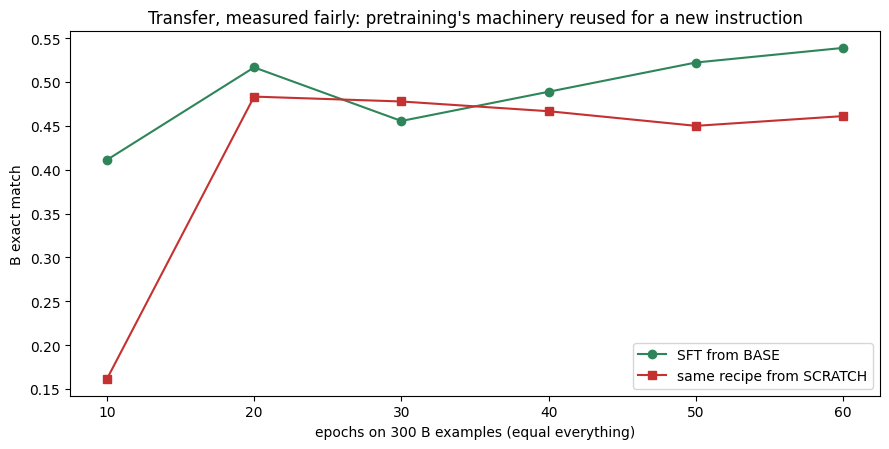

from BASE:    10 epochs -> 41%   60 epochs -> 54%
from SCRATCH: 10 epochs -> 16%   60 epochs -> 46%
Faster at every checkpoint, higher at the end: the digit embeddings, format circuits and
answer template were already built — SFT only had to steer them (README §2.2).


In [4]:
def eval_b(m_): return exact_match(m_, Xb_te)

sft = LM(V, T, seed=3)
sft.P = {k: v.copy() for k, v in base.P.items()}          # start from BASE
h_base = sft.train(Xb, epochs=60, lr=1e-3, batch=64, seed=1, eval_fn=eval_b, eval_every=10)

scratch = LM(V, T, seed=3)                                 # identical init seed, NO pretraining
h_scr = scratch.train(Xb, epochs=60, lr=1e-3, batch=64, seed=1, eval_fn=eval_b, eval_every=10)

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot([e for e, _ in h_base["eval"]], [v for _, v in h_base["eval"]], "o-", color="#2f855a", label="SFT from BASE")
ax.plot([e for e, _ in h_scr["eval"]], [v for _, v in h_scr["eval"]], "s-", color="#c53030", label="same recipe from SCRATCH")
ax.set_xlabel("epochs on 300 B examples (equal everything)"); ax.set_ylabel("B exact match"); ax.legend()
ax.set_title("Transfer, measured fairly: pretraining's machinery reused for a new instruction")
plt.tight_layout(); plt.show()

print(f"from BASE:    10 epochs -> {dict(h_base['eval'])[10]:.0%}   60 epochs -> {dict(h_base['eval'])[60]:.0%}")
print(f"from SCRATCH: 10 epochs -> {dict(h_scr['eval'])[10]:.0%}   60 epochs -> {dict(h_scr['eval'])[60]:.0%}")
print("Faster at every checkpoint, higher at the end: the digit embeddings, format circuits and")
print("answer template were already built — SFT only had to steer them (README §2.2).")

## Block 4 — The other edge: forgetting, then the replay cure *(README §2.2)*

SFT steers by gradient — and gradients on B-only data are free to overwrite S. Measure the damage, then apply the standard industrial cure: mix old data back into the diet.

In [5]:
em_s_after = exact_match(sft, Xs_te)
print(f"catastrophic forgetting: S-task {exact_match(base, Xs_te):.1%} (base) -> {em_s_after:.1%} after B-only SFT\n")

mix = LM(V, T, seed=3)
mix.P = {k: v.copy() for k, v in base.P.items()}
Xmix = np.concatenate([Xb, encode([seq_str("S", a, b) for a, b in S_train[:300]])])
mix.train(Xmix, epochs=60, lr=1e-3, batch=64, seed=1)
em_b_mix, em_s_mix = exact_match(mix, Xb_te), exact_match(mix, Xs_te)
print(f"REPLAY (300 B + 300 old S, same budget): B {em_b_mix:.1%} | S {em_s_mix:.1%}")
print("Three hundred remembered examples buy back the old skill almost entirely. Every serious")
print("fine-tune mixes data for exactly this reason (README §4). This 'mix' model — competent")
print("at both tasks, imperfect at B — is our policy for the reward experiments ahead.")

catastrophic forgetting: S-task 100.0% (base) -> 1.5% after B-only SFT



REPLAY (300 B + 300 old S, same budget): B 51.1% | S 93.2%
Three hundred remembered examples buy back the old skill almost entirely. Every serious
fine-tune mixes data for exactly this reason (README §4). This 'mix' model — competent
at both tasks, imperfect at B — is our policy for the reward experiments ahead.


## Block 5 — The sampling toolbox: one distribution, four spigots *(README §3.3)*

Nothing in this block trains — sampling is policy at inference time. On the same mix model and the same 100 fresh B prompts, measure each spigot's trade: correctness vs diversity (distinct answers across 6 draws).

In [6]:
def sample_full(model, prompt_toks, n, seed, policy):
    rs = np.random.default_rng(seed)
    m = len(prompt_toks)
    outs = np.zeros((m, n, 3), dtype=int)
    for k in range(n):
        cur = prompt_toks.copy(); cur[:, 7:] = STOI[";"]
        for pos in range(7, 10):
            lg, _ = model.forward(cur)
            z = lg[:, pos-1]
            if policy["kind"] == "greedy":
                cur[:, pos] = z.argmax(-1); continue
            pr = softmax(z / policy["temp"])
            if policy["kind"] == "topk":
                kk = policy["k"]
                idx = np.argsort(pr, 1)[:, -kk:]
                mask = np.zeros_like(pr); np.put_along_axis(mask, idx, 1.0, 1)
                pr = pr * mask; pr /= pr.sum(1, keepdims=True)
            elif policy["kind"] == "topp":
                order = np.argsort(pr, 1)[:, ::-1]
                srt = np.take_along_axis(pr, order, 1)
                keep_sorted = np.cumsum(srt, 1) - srt < policy["p"]   # smallest set reaching p
                mask = np.zeros_like(pr)
                np.put_along_axis(mask, order, keep_sorted.astype(float), 1)
                pr = pr * mask; pr /= pr.sum(1, keepdims=True)
            cur[:, pos] = np.array([rs.choice(V, p=pr[i]) for i in range(m)])
        outs[:, k] = cur[:, 7:10]
    return outs

ptoks = Xb_te[:100]
truths = ptoks[:, 7:10]
policies = [("greedy", {"kind": "greedy"}),
            ("temp 0.8", {"kind": "temp", "temp": 0.8}),
            ("temp 1.5", {"kind": "temp", "temp": 1.5}),
            ("top-k=3 @ 1.5", {"kind": "topk", "temp": 1.5, "k": 3}),
            ("top-p=0.9 @ 1.5", {"kind": "topp", "temp": 1.5, "p": 0.9})]
print(f"{'policy':>16s} {'correct':>9s} {'distinct answers/prompt':>25s}")
for name, pol in policies:
    outs = sample_full(mix, ptoks, 6, seed=5, policy=pol)
    corr = (outs == truths[:, None, :]).all(-1).mean()
    distinct = np.mean([len({tuple(outs[i, k]) for k in range(6)}) for i in range(100)])
    print(f"{name:>16s} {corr:>9.0%} {distinct:>25.2f}")
print()
print("The trade, measured: greedy maximizes single-shot correctness with zero diversity;")
print("raw temperature buys diversity by manufacturing errors; top-k and top-p claw back")
print("correctness by cutting the tail — top-p adaptively (narrow when sure, wide when not),")
print("which is why it's the production default. Diversity isn't waste: it's what best-of-N")
print("(next blocks) harvests — IF the judge is good (README §3.3).")

          policy   correct   distinct answers/prompt
          greedy       48%                      1.00


        temp 0.8       47%                      1.53
        temp 1.5       39%                      2.56


   top-k=3 @ 1.5       42%                      2.21
 top-p=0.9 @ 1.5       44%                      1.88

The trade, measured: greedy maximizes single-shot correctness with zero diversity;
raw temperature buys diversity by manufacturing errors; top-k and top-p claw back
correctness by cutting the tail — top-p adaptively (narrow when sure, wide when not),
which is why it's the production default. Diversity isn't waste: it's what best-of-N
(next blocks) harvests — IF the judge is good (README §3.3).


## Block 6 — The reward model: lesson 02's sigmoid, reborn on differences *(README §3.2)*

A judge: a small (non-causal) transformer encoder → mean-pool → scalar score, trained on PREFERENCES via Bradley-Terry: −log σ(score(chosen) − score(rejected)). Two judges trained live, differing ONLY in what their preference data distinguishes: **RM-POLICY** (correct vs wrong among the mix model's OWN samples — the distribution it will actually judge) and **RM-FORMAT** (correct vs malformed — a pure surface proxy). Their held-out accuracies foreshadow everything.

In [7]:
def sample_completions(model, prompt_toks, n, temp, seed=0):
    rs = np.random.default_rng(seed)
    m = len(prompt_toks)
    outs = np.zeros((m, n, 4), dtype=int)
    for k in range(n):
        cur = prompt_toks.copy(); cur[:, 7:] = STOI[";"]
        for pos in range(7, T):
            lg, _ = model.forward(cur)
            pr = softmax(lg[:, pos-1] / temp)
            cur[:, pos] = np.array([rs.choice(V, p=pr[i]) for i in range(m)])
        outs[:, k] = cur[:, 7:]
    return outs

class RewardModel:
    """Encoder -> mean-pool -> scalar; Bradley-Terry trained (README §3.2)."""
    def __init__(self, seed=0):
        self.lm = LM(V, T, D=24, LAYERS=1, HEADS=4, FF=48, seed=seed, causal=False)
        rs = np.random.default_rng(seed + 100)
        self.w = rs.normal(0, 0.15, 24)
    def score(self, toks):
        logits, cache = self.lm.forward(toks)
        Xf = cache[2]
        pooled = Xf.mean(1)
        return pooled @ self.w, (cache, pooled)
    def bt_step(self, Xw, Xl, opt_lm, lr_w):
        rw, (cw, pw) = self.score(Xw)
        rl, (cl, pl) = self.score(Xl)
        margin = rw - rl
        sig = 1 / (1 + np.exp(margin))                     # σ(−margin): the (guess−truth) of preference
        L = np.mean(np.log(1 + np.exp(-margin)))
        m = len(Xw)
        dw = (-(sig[:, None] * pw).mean(0) + (sig[:, None] * pl).mean(0))
        def tower_back(cache, dpooled):
            tok, caches, Xf, lcF = cache
            dXf = np.broadcast_to(dpooled[:, None, :] / T, Xf.shape).copy()
            G = {k: np.zeros_like(v) for k, v in self.lm.P.items()}
            P = self.lm.P
            dX, G["gF"], G["bF"] = layernorm_back(dXf, P["gF"], lcF)
            for l in range(self.lm.L - 1, -1, -1):
                A_in, lc1, Q, K, Vv, A, X1, F_in, lc2, Hf = caches[l]
                dHf = (dX @ P[f"W2_{l}"].T) * (Hf > 0)
                G[f"W2_{l}"] = np.einsum("mtf,mtd->fd", Hf, dX); G[f"c2_{l}"] = dX.sum((0, 1))
                G[f"W1_{l}"] = np.einsum("mtd,mtf->df", F_in, dHf); G[f"c1_{l}"] = dHf.sum((0, 1))
                dX1_ln, G[f"g2_{l}"], G[f"b2_{l}"] = layernorm_back(dHf @ P[f"W1_{l}"].T, P[f"g2_{l}"], lc2)
                dX1 = dX + dX1_ln
                Om = self.lm.mh(A @ Vv)
                G[f"Wo_{l}"] = np.einsum("mtd,mte->de", Om, dX1)
                dOhd = self.lm.sh(dX1 @ P[f"Wo_{l}"].T)
                dA = dOhd @ Vv.transpose(0, 1, 3, 2)
                dVv = A.transpose(0, 1, 3, 2) @ dOhd
                dS = (A * (dA - (dA * A).sum(-1, keepdims=True))) / np.sqrt(self.lm.DH)
                dQ = dS @ K; dK = dS.transpose(0, 1, 3, 2) @ Q
                dA_in = self.lm.mh(dQ) @ P[f"Wq_{l}"].T + self.lm.mh(dK) @ P[f"Wk_{l}"].T + self.lm.mh(dVv) @ P[f"Wv_{l}"].T
                G[f"Wq_{l}"] = np.einsum("mtd,mte->de", A_in, self.lm.mh(dQ))
                G[f"Wk_{l}"] = np.einsum("mtd,mte->de", A_in, self.lm.mh(dK))
                G[f"Wv_{l}"] = np.einsum("mtd,mte->de", A_in, self.lm.mh(dVv))
                dX_ln, G[f"g1_{l}"], G[f"b1_{l}"] = layernorm_back(dA_in, P[f"g1_{l}"], lc1)
                dX = dX1 + dX_ln
            G["Pos"] = dX.sum(0)
            np.add.at(G["E"], tok, dX)
            G["Wout"] = np.zeros_like(P["Wout"])
            return G
        dpw = -(sig[:, None] * self.w[None]) / m
        dpl = (sig[:, None] * self.w[None]) / m
        Gw = tower_back(cw, dpw)
        Gl = tower_back(cl, dpl)
        G = {k: Gw[k] + Gl[k] for k in Gw}
        opt_lm.step(self.lm.P, G)
        self.w -= lr_w * dw
        return L
    def train_bt(self, Xw, Xl, epochs=12, lr=1e-3, seed=0):
        opt = Adam(self.lm.P, lr)
        rs = np.random.default_rng(seed)
        for ep in range(epochs):
            order = rs.permutation(len(Xw))
            for s_ in range(0, len(Xw), 64):
                b = order[s_:s_+64]
                self.bt_step(Xw[b], Xl[b], opt, lr)

rng = np.random.default_rng(5)
train_prompts = [("S", a, b) for a, b in S_test[300:900]] + [("B", a, b) for a, b in B_test[:120]]
tr_ptoks = encode([seq_str(t, a, b) for t, a, b in train_prompts])
tr_samples = sample_completions(mix, tr_ptoks, 8, 2.0, seed=11)   # the policy's OWN outputs
tr_truths = tr_ptoks[:, 7:]
Xw_p, Xl_p = [], []
for i in range(len(tr_ptoks)):
    ok = [(tr_samples[i, k, :3] == tr_truths[i, :3]).all() for k in range(8)]
    goods = [k for k in range(8) if ok[k]][:3]; bads = [k for k in range(8) if not ok[k]][:3]
    for g_ in goods:
        for b_ in bads:
            Xw_p.append(np.concatenate([tr_ptoks[i, :7], tr_samples[i, g_]]))
            Xl_p.append(np.concatenate([tr_ptoks[i, :7], tr_samples[i, b_]]))
Xw_p, Xl_p = np.array(Xw_p), np.array(Xl_p)

def completion_tokens_malformed(task, a, b):
    ans = a + b if task == "S" else max(a, b)
    choice = rng.integers(0, 3)
    if choice == 0: s = f"{ans:03d}" + str(rng.integers(0, 10))
    elif choice == 1: s = ";" + f"{ans % 1000:03d}"
    else: s = "+" + f"{ans % 100:02d}" + ";"
    return [STOI[c] for c in s]
Xw_f, Xl_f = [], []
for task, a, b in train_prompts:
    pre = [STOI[c] for c in seq_str(task, a, b)[:7]]
    ans = a + b if task == "S" else max(a, b)
    Xw_f.append(pre + [STOI[c] for c in f"{ans:03d};"])
    Xl_f.append(pre + completion_tokens_malformed(task, a, b))
Xw_f, Xl_f = np.array(Xw_f), np.array(Xl_f)

def fit_rm(Xw, Xl, name):
    cut = int(0.85 * len(Xw))
    rm = RewardModel(seed=0)
    rm.train_bt(Xw[:cut], Xl[:cut], epochs=12, lr=1e-3)
    ho = (rm.score(Xw[cut:])[0] > rm.score(Xl[cut:])[0]).mean()
    print(f"{name}: held-out pair accuracy {ho:.0%}")
    return rm
print(f"preference pairs from the policy's own samples: {len(Xw_p)}")
rm_policy = fit_rm(Xw_p, Xl_p, "RM-POLICY (right vs the model's own wrong)")
rm_fmt = fit_rm(Xw_f, Xl_f, "RM-FORMAT (right vs malformed)            ")
print()
print("Read those numbers as prophecy: format is trivially learnable; distinguishing the")
print("policy's plausible errors from its correct answers is HARD — and best-of-N is about")
print("to amplify exactly that difference (README §3.2, §2.3).")

preference pairs from the policy's own samples: 4269


RM-POLICY (right vs the model's own wrong): held-out pair accuracy 59%


RM-FORMAT (right vs malformed)            : held-out pair accuracy 100%

Read those numbers as prophecy: format is trivially learnable; distinguishing the
policy's plausible errors from its correct answers is HARD — and best-of-N is about
to amplify exactly that difference (README §3.2, §2.3).


## Block 7 — Best-of-N, four judges: Goodhart arrives on schedule *(README §2.3)*

Fresh prompts, disjoint from every judge's diet. Sample 8 noisy answers each (τ=2.0), let four judges pick: nobody (first sample), a TRUE verifier (checks the arithmetic — the oracle), the learned RM-POLICY, and RM-FORMAT. Grade what each judge's favorite is actually worth.

In [8]:
eval_prompts = [("S", a, b) for a, b in S_test[900:1000]] + [("B", a, b) for a, b in B_test[120:180]]
ptoks = encode([seq_str(t, a, b) for t, a, b in eval_prompts])
N, TEMP = 8, 2.0
samples = sample_completions(mix, ptoks, N, TEMP, seed=9)
truths = ptoks[:, 7:]

def grade(picked):
    corr = (picked[:, :3] == truths[:, :3]).all(1).mean()
    wellformed = np.array([all(t < 10 for t in row[:3]) and row[3] == STOI[";"] for row in picked]).mean()
    return corr, wellformed

def bon(rm):
    picked = np.zeros_like(samples[:, 0])
    for i in range(len(ptoks)):
        cands = np.concatenate([np.repeat(ptoks[i:i+1, :7], N, 0), samples[i]], 1)
        scores, _ = rm.score(cands)
        picked[i] = samples[i][scores.argmax()]
    return grade(picked)

orc = np.zeros_like(samples[:, 0])
for i in range(len(ptoks)):
    ok = [(samples[i, k, :3] == truths[i, :3]).all() for k in range(N)]
    orc[i] = samples[i][ok.index(True) if any(ok) else 0]

rows = [("no selection (1 sample)", grade(samples[:, 0])),
        (f"best-of-{N}, TRUE verifier", grade(orc)),
        (f"best-of-{N}, RM-POLICY", bon(rm_policy)),
        (f"best-of-{N}, RM-FORMAT", bon(rm_fmt))]
print(f"{'judge':>26s} {'CORRECT':>9s} {'well-formed':>13s}")
for name, (c_, f_) in rows:
    print(f"{name:>26s} {c_:>9.0%} {f_:>13.0%}")
print()
print("Three lessons in one table (README §2.3):")
print(" 1) The TRUE verifier soars — correct answers EXIST among the samples; a perfect judge")
print("    harvests them. (Why verifiable domains love reward optimization.)")
print(" 2) The learned RM does WORSE than no selection: argmax-of-8 doesn't sample the judge's")
print("    average opinion, it hunts the judge's most-confident opinion — which for a weak")
print("    judge is where its errors concentrate. Optimization pressure AMPLIFIES proxy error.")
print(" 3) RM-FORMAT: the proxy (format) improves; the target (correctness) sinks. Goodhart,")
print("    verbatim. RLHF internalizes these dynamics into the weights — hence the KL leash.")

                     judge   CORRECT   well-formed
   no selection (1 sample)       51%           92%
  best-of-8, TRUE verifier       93%           97%
      best-of-8, RM-POLICY       39%           89%
      best-of-8, RM-FORMAT       36%           97%

Three lessons in one table (README §2.3):
 1) The TRUE verifier soars — correct answers EXIST among the samples; a perfect judge
    harvests them. (Why verifiable domains love reward optimization.)
 2) The learned RM does WORSE than no selection: argmax-of-8 doesn't sample the judge's
    average opinion, it hunts the judge's most-confident opinion — which for a weak
    judge is where its errors concentrate. Optimization pressure AMPLIFIES proxy error.
 3) RM-FORMAT: the proxy (format) improves; the target (correctness) sinks. Goodhart,
    verbatim. RLHF internalizes these dynamics into the weights — hence the KL leash.


## Block 8 — In-context learning, rung 1: lookup with frozen weights *(README §2.4)*

Each sequence carries a PRIVATE random digit→digit mapping: `"3>7;5>9;3>7;..."`. When a query repeats, its answer sits in the context — retrievable by the induction mechanism (find the previous occurrence, copy what followed). The model below was pretrained on 65 epochs of such sequences (training code in the next block's disclosure; weights shipped in `data/`). Evaluation is live, on fresh sequences: the WEIGHTS ARE FROZEN — only the prompt teaches.

In [9]:
IV = list("0123456789>;")
ISTOI = {c: i for i, c in enumerate(IV)}
IT = 16
m_ind = LM(len(IV), IT, seed=0)
m_ind.P = np.load("data/induction_weights.npy", allow_pickle=True).item()

irng = np.random.default_rng(999)
def make_seq(rs):
    Mp = {}
    qs = rs.integers(0, 10, 4)
    for q in qs:
        if q not in Mp: Mp[q] = int(rs.integers(0, 10))
    return "".join(f"{q}>{Mp[q]};" for q in qs), qs
test = [make_seq(irng) for _ in range(3000)]
Xt = np.array([[ISTOI[c] for c in s] for s, _ in test])
lg, _ = m_ind.forward(Xt)
pred = lg.argmax(-1)
firsts, repeats = [], []
for i, (s, qs) in enumerate(test):
    seen = set()
    for j, q in enumerate(qs):
        pos = 4 * j + 2
        (repeats if q in seen else firsts).append(pred[i, pos - 1] == Xt[i, pos])
        seen.add(q)
print(f"example sequence: {test[0][0]!r}  (its mapping exists ONLY in this sequence)")
print(f"FIRST occurrence of a query (mapping unknowable): {np.mean(firsts):.1%}   (chance 10% — and an honest model CAN'T beat it)")
print(f"REPEAT occurrence (answer sits in the context):   {np.mean(repeats):.1%}")
print()
print("No gradient touched these weights during evaluation. The forward pass ITSELF performs the")
print("lookup — an induction circuit built by ordinary pretraining. Historical note reproduced in")
print("miniature: the skill emerged LATE and fast (57% -> 62% -> 84% across training phases) —")
print("the induction-head phase change (README §2.4).")

example sequence: '8>1;7>7;1>1;1>1;'  (its mapping exists ONLY in this sequence)
FIRST occurrence of a query (mapping unknowable): 10.1%   (chance 10% — and an honest model CAN'T beat it)
REPEAT occurrence (answer sits in the context):   84.3%

No gradient touched these weights during evaluation. The forward pass ITSELF performs the
lookup — an induction circuit built by ordinary pretraining. Historical note reproduced in
miniature: the skill emerged LATE and fast (57% -> 62% -> 84% across training phases) —
the induction-head phase change (README §2.4).


## Block 9 — Rung 2 and the scaling curve: the long experiments, disclosed *(README §2.4–2.5)*

Two experiments too slow for a notebook (≈45 min combined) ship as results in `data/`, with their generating code in `generate_assets_17.py` stages `icl`/`scale` and budgets printed below — the honest way to include them. Rung 2: sequences follow x → x+k (mod 10), k fixed per sequence; the model must INFER k from examples. Scaling: four sizes, same data and steps, excess loss above the floor.

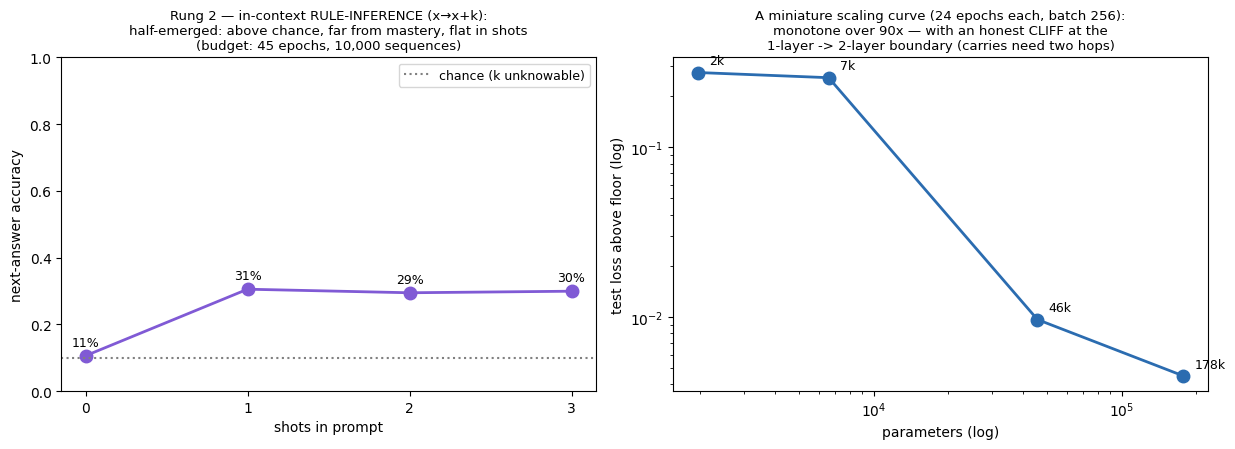

Two honest readings:
 - ICL is a LADDER: lookup (Block 8: 84%) arrives early; latent-rule inference (~30%,
   flat) is a scale-bought skill our 46k parameters only begin to climb.
 - The scaling curve is monotone but RAGGED: the cliff between 6.6k and 46k lands exactly
   where 2 layers first make the carry circuit possible (lesson 14 §4's prediction).
   Industrial power laws are smooth because they AVERAGE thousands of such cliffs —
   which is also why per-skill 'emergence' and smooth aggregate curves coexist (README §2.5).


In [10]:
icl = pd.read_csv("data/icl_results.csv")
scale = pd.read_csv("data/scale_results.csv")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
ax = axes[0]
ax.plot(icl.shots, icl.kshift_acc, "o-", lw=2, color="#805ad5", markersize=9)
for s_, a_ in zip(icl.shots, icl.kshift_acc):
    ax.text(s_, a_ + 0.03, f"{a_:.0%}", ha="center", fontsize=9)
ax.axhline(0.1, color="gray", ls=":", label="chance (k unknowable)")
ax.set_xticks([0, 1, 2, 3]); ax.set_xlabel("shots in prompt"); ax.set_ylabel("next-answer accuracy")
ax.set_ylim(0, 1.0); ax.legend(fontsize=9)
ax.set_title("Rung 2 — in-context RULE-INFERENCE (x→x+k):\nhalf-emerged: above chance, far from mastery, flat in shots\n(budget: 45 epochs, 10,000 sequences)", fontsize=9.5)
ax = axes[1]
excess = np.maximum(scale.test_loss - scale.floor, 1e-4)
ax.loglog(scale.params, excess, "o-", lw=2, color="#2b6cb0", markersize=9)
for p, e in zip(scale.params, excess):
    ax.annotate(f"{p/1000:.0f}k", (p, e), textcoords="offset points", xytext=(8, 6), fontsize=9)
ax.set_xlabel("parameters (log)"); ax.set_ylabel("test loss above floor (log)")
ax.set_title("A miniature scaling curve (24 epochs each, batch 256):\nmonotone over 90x — with an honest CLIFF at the\n1-layer -> 2-layer boundary (carries need two hops)", fontsize=9.5)
plt.tight_layout(); plt.show()

print("Two honest readings:")
print(" - ICL is a LADDER: lookup (Block 8: 84%) arrives early; latent-rule inference (~30%,")
print("   flat) is a scale-bought skill our 46k parameters only begin to climb.")
print(" - The scaling curve is monotone but RAGGED: the cliff between 6.6k and 46k lands exactly")
print("   where 2 layers first make the carry circuit possible (lesson 14 §4's prediction).")
print("   Industrial power laws are smooth because they AVERAGE thousands of such cliffs —")
print("   which is also why per-skill 'emergence' and smooth aggregate curves coexist (README §2.5).")

## Block 10 — Calibration: the mechanical seed of hallucination — and the course's last block *(README §5, §6)*

Ask the mix model B-questions it half-knows; record its OWN probability for each answer it emits; split by whether the answer was right. If the two confidence distributions overlap, confidence is not evidence — the property that, at every scale, turns fluent output into confident fabrication.

answers graded: 51% correct
mean self-confidence when RIGHT: 0.85
mean self-confidence when WRONG: 0.79
answers delivered with >90% confidence that are WRONG: 33 of 180


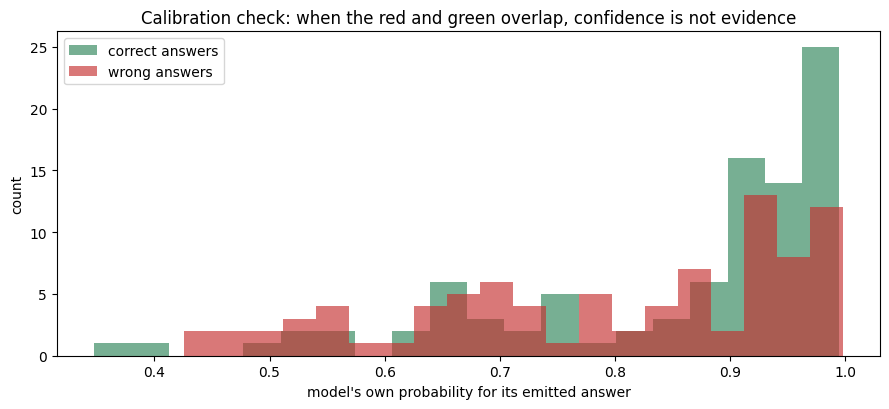


The overlap is the point: softmax must spend its budget, so the model answers with
conviction whether or not conviction is earned — the mechanical seed of hallucination,
identical at 46 thousand parameters and 46 billion. The cure is never 'trust the tone':
it is verification, calibration measurement, and honest evaluation — the habits this
course practiced on every single lesson (README §6).


In [11]:
cur = Xb_te.copy(); cur[:, 7:] = STOI[";"]
confs = np.ones(len(cur))
for pos in range(7, 10):
    lg, _ = mix.forward(cur)
    pr = softmax(lg[:, pos-1])
    cur[:, pos] = pr.argmax(-1)
    confs *= pr[np.arange(len(cur)), cur[:, pos]]
right = (cur[:, 7:10] == Xb_te[:, 7:10]).all(1)
print(f"answers graded: {right.mean():.0%} correct")
print(f"mean self-confidence when RIGHT: {confs[right].mean():.2f}")
print(f"mean self-confidence when WRONG: {confs[~right].mean():.2f}")
hi_conf_wrong = ((confs > 0.9) & ~right).sum()
print(f"answers delivered with >90% confidence that are WRONG: {hi_conf_wrong} of {len(cur)}")

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.hist(confs[right], bins=20, alpha=0.65, color="#2f855a", label="correct answers")
ax.hist(confs[~right], bins=20, alpha=0.65, color="#c53030", label="wrong answers")
ax.set_xlabel("model's own probability for its emitted answer"); ax.set_ylabel("count"); ax.legend()
ax.set_title("Calibration check: when the red and green overlap, confidence is not evidence")
plt.tight_layout(); plt.show()

print()
print("The overlap is the point: softmax must spend its budget, so the model answers with")
print("conviction whether or not conviction is earned — the mechanical seed of hallucination,")
print("identical at 46 thousand parameters and 46 billion. The cure is never 'trust the tone':")
print("it is verification, calibration measurement, and honest evaluation — the habits this")
print("course practiced on every single lesson (README §6).")

---
## What you now own — and the course, closed

- The pipeline as one loop, three teachers: pretraining (corpus), SFT (curation — with transfer and forgetting both measured), preferences (a learned judge — with its economics measured)
- Bradley-Terry: preference learning as lesson 02's sigmoid on score differences
- The Goodhart table: verifier 93%, weak judge BELOW baseline, format proxy polishing the surface — selection is only as good as the judge, and pressure amplifies the gap
- The sampling toolbox, measured: greedy / temperature / top-k / top-p / best-of-N
- ICL as a ladder: induction lookup at 84% with frozen weights; rule-inference half-emerged
- A ragged miniature scaling curve with a mechanistic cliff — and why industrial laws look smooth
- Calibration as the two-minute check that separates fluency from knowledge

Seventeen lessons ago this repository began with w·x + b. The loop never changed; everything else was losses, architectures — and the discipline of measuring honestly. **The machinery is yours now. Measure honestly.**

**Next:** `llm_concepts_with_library.ipynb` — verifications, the scale ledger, and the map from every block here to the production stack.